In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import gc
import jax
gc.collect()
jax.clear_caches()

import superstats as sup
import numpy as np

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
import os
print(os.getpid())

4185182


In [3]:
!nvidia-smi

/scicore/home/rieskamp/schuma0018/.local/share/uv/python/cpython-3.13.14-linux-x86_64-gnu/lib/python3.13/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Mon Sep 21 19:38:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:01:00.0 Off |                  Off |
| 30%   38C    P8             18W /  450W |   18959MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Transitions and priors define raw inference targets. Parameter constraints are applied by `Model.link_function` after formula resolution. Prior plots belong to `Model` and show raw inference targets. See [the regression and links migration guide](https://github.com/LuSchumacher/superstats/blob/main/docsrc/user_guide/regression_and_links.md).

## Constants

In [4]:
NUM_STEPS = 480
NUM_SAMPLES = 1000

## Context

In [5]:
def generate_context(num_steps):
    conditions = [
        (0.5, 0.5),   # high difficulty, high reward
        (0.5, -0.5),  # high difficulty, low reward
        (-0.5, 0.5),  # low difficulty, high reward
        (-0.5, -0.5), # low difficulty, low reward
    ]
    num_blocks = (num_steps + 59) // 60
    conditions = (conditions * ((num_blocks + len(conditions) - 1) // len(conditions)))[:num_blocks]
    np.random.shuffle(conditions)
    difficulty = []
    reward = []
    remaining_steps = num_steps
    for difficulty_code, reward_code in conditions:
        block_steps = min(60, remaining_steps)
        difficulty.extend([difficulty_code] * block_steps)
        reward.extend([reward_code] * block_steps)
        remaining_steps -= block_steps
    return {
        "difficulty": difficulty,
        "reward": reward,
    }

In [6]:
context = sup.ContextSimulator(
    simulator=generate_context,
    is_batched=False
)

## Prior

In [7]:
formula = sup.Formula([
    "v = v_0 + b_v_1 * difficulty + b_v_2 * reward + b_v_3 * difficulty * reward",
    "a = a_0 + b_a_1 * difficulty + b_a_2 * reward + b_a_3 * difficulty * reward",
    "tau = tau_0 + b_tau_1 * difficulty + b_tau_2 * reward + b_tau_3 * difficulty * reward",
])

prior = sup.JointPrior(
    v_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_v_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_v_3=sup.Prior("normal", loc=0.0, scale=2.0),
    a_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=-1.0, scale=1.0),
        sigma=sup.Prior("halfnormal", scale=0.15),
    ),
    b_a_1=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_2=sup.Prior("normal", loc=0.0, scale=2.0),
    b_a_3=sup.Prior("normal", loc=0.0, scale=2.0),
    tau_0=sup.transition.RandomWalk(
        initial_prior=sup.Prior("normal", loc=0.0, scale=0.75),
        sigma=sup.Prior("halfnormal", scale=0.075),
    ),
    b_tau_1=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_2=sup.Prior("normal", loc=0.0, scale=0.5),
    b_tau_3=sup.Prior("normal", loc=0.0, scale=0.5),
    bias=0.5,
    p_missing=sup.Prior("beta", a=1.5, b=15.0),
)

In [8]:
missing_process = sup.simulation.RandomMissingProcess(
    missing_value=-1,
)

model = sup.Model(
    prior=prior,
    simulator=sup.simulation.sample_ddm,
    link_function={
        'v': sup.LinkFunction(bounds=(0.0, 8.0)),
        'a': sup.LinkFunction(bounds=(0.0, 6.0)),
        'tau': sup.LinkFunction(bounds=(0.0, 1.0))
    }, 
    formula=formula,
    context=context,
    design_context=('difficulty', 'reward'),
    missing=missing_process,
)

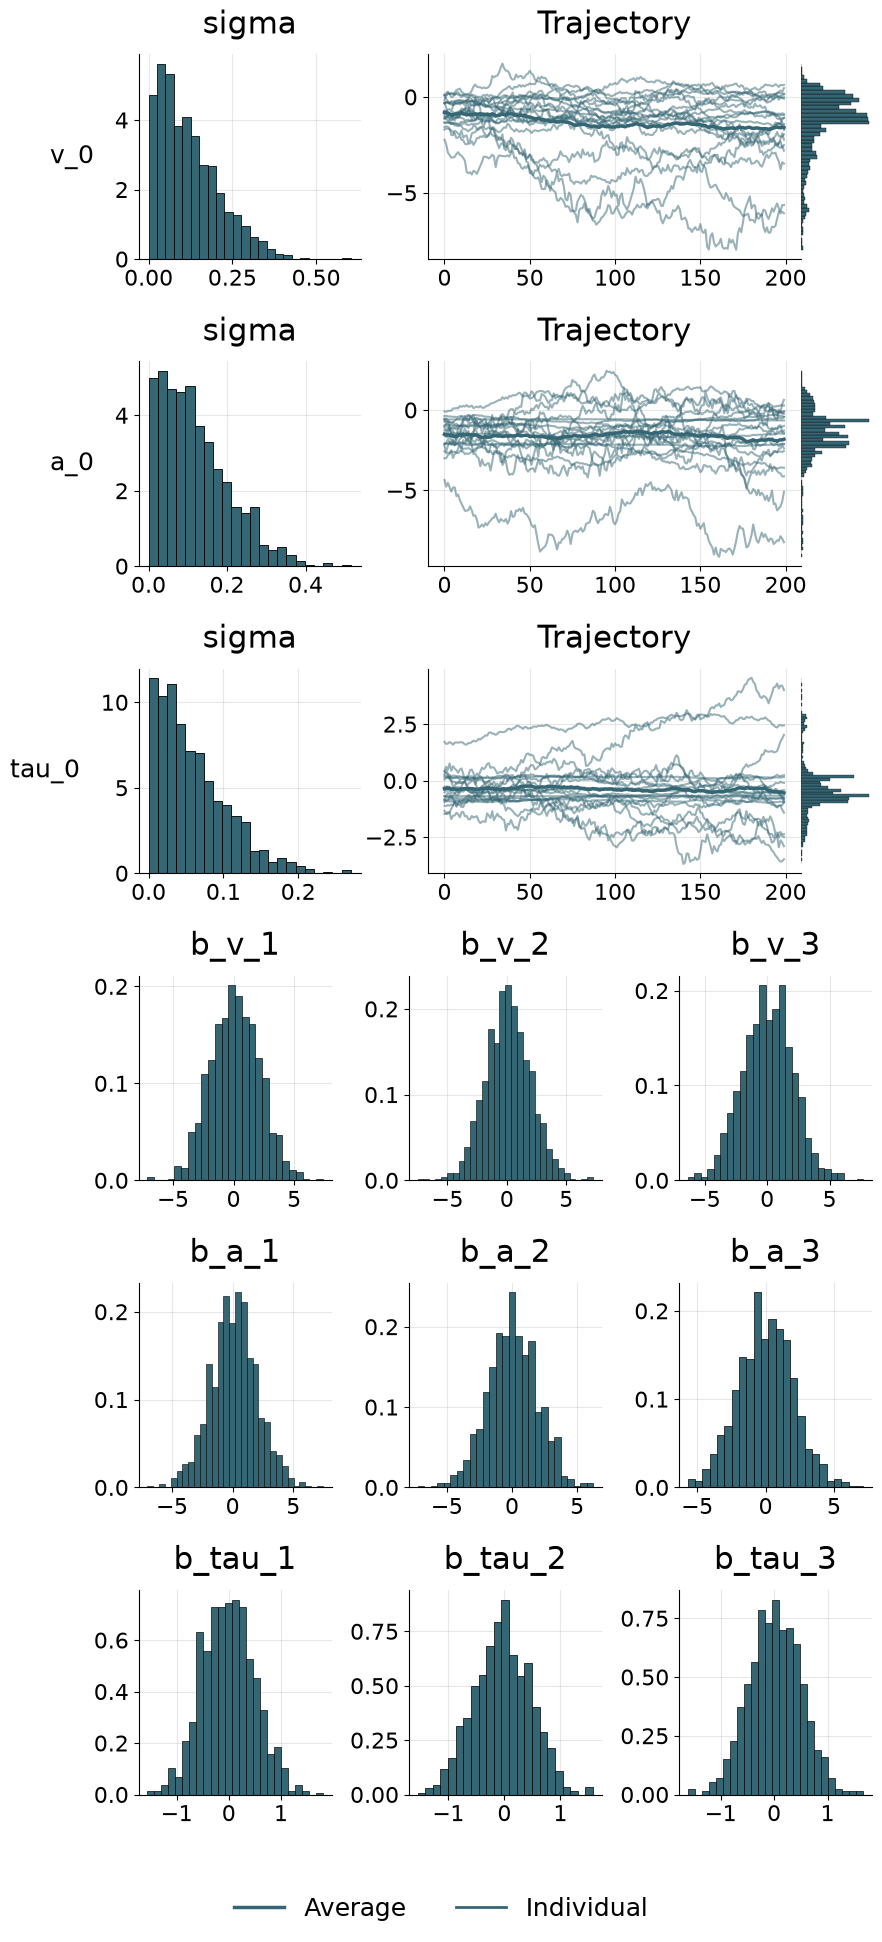

In [9]:
fig = model.plot_joint_prior()

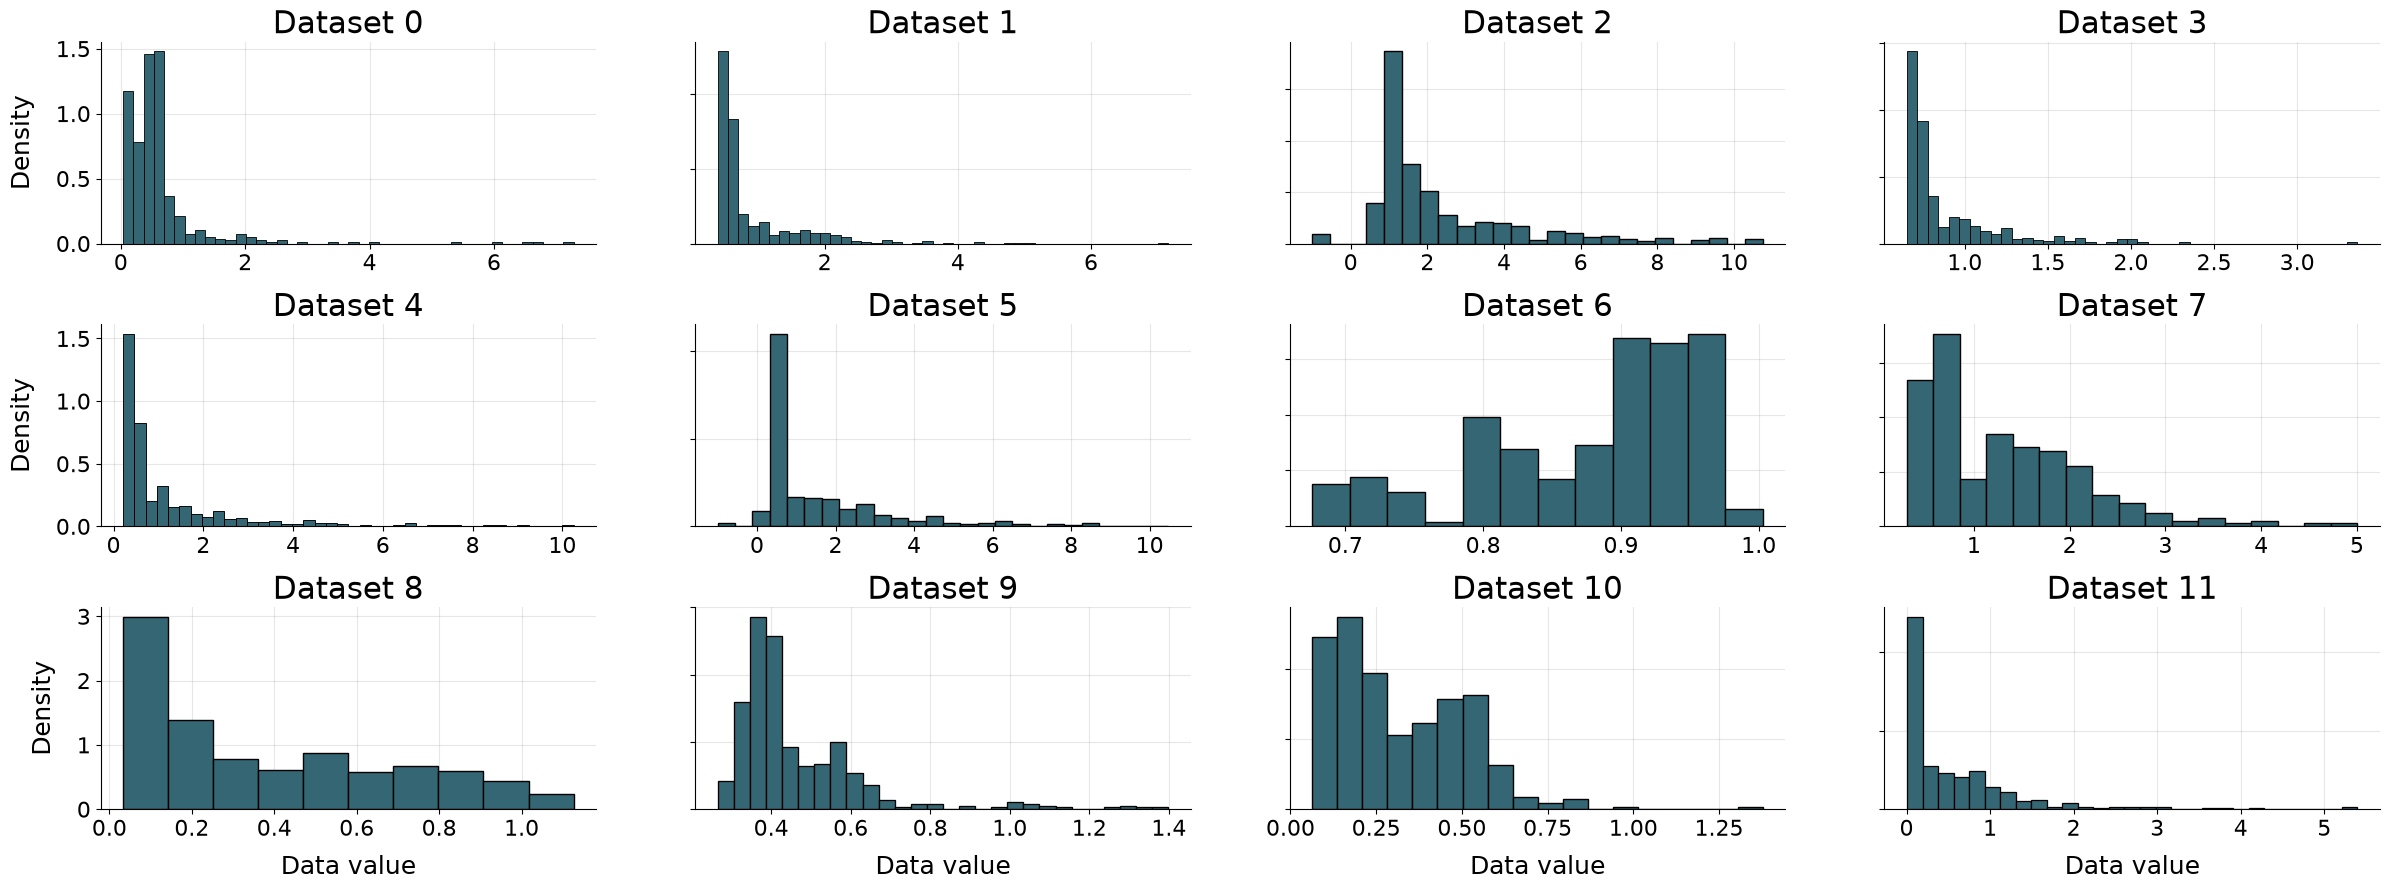

In [11]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist"
)

## Approximator Training

In [12]:
workflow = sup.Workflow(
    model=model,
    approximator="joint",
    mode="smoothing",
    checkpoint_filepath="checkpoints/ms_study_ddm_regressors_v01"
)

In [13]:
train_data = model.sample(
    batch_size=30_000,
    num_steps=NUM_STEPS
)

val_data = model.sample(
    batch_size=200,
    num_steps=NUM_STEPS
)

In [14]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - invariant/loss: 16.0715 - loss: 17.2591 - varying/loss: 1.1876 - val_invariant/loss: 15.6258 - val_loss: 16.4798 - val_varying/loss: 0.8540
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - invariant/loss: 14.4303 - loss: 12.0803 - varying/loss: -2.3500 - val_invariant/loss: 16.4770 - val_loss: 13.4182 - val_varying/loss: -3.0587
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - invariant/loss: 13.5881 - loss: 10.2058 - varying/loss: -3.3823 - val_invariant/loss: 13.5912 - val_loss: 9.9052 - val_varying/loss: -3.6860
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - invariant/loss: 13.0125 - loss: 8.7397 - varying/loss: -4.2727 - val_invariant/loss: 13.5828 - val_loss: 9.5494 - val_varying/loss: -4.0334
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - invariant/loss: 12.9726 - loss: 8.7594 - varying/loss: -4.2132 - val_invariant/loss: 11.1706 - val_loss: 6.3535 - val_varying/loss: -4.8171
Epoch 6/50
938/

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
# history = workflow.fit_online(
#     num_steps=NUM_STEPS,
#     epochs=100,
#     num_batches_per_epoch=1000,
#     batch_size=32
# )

In [ ]:
fig = workflow.plot_history(workflow.history)